# 测量系统分析：某州度量衡校准实验室的量具重复性与再现性（Gage R&R）研究

## 摘要

某州度量衡管理部门开展了一项量具重复性与再现性（Gage R&R）研究，用以认证检验员用来核查
商用秤具的天平。由于 SAS/QC 将 Gage R&R 作为交互式的 **GAGE** SAS/AF 应用提供
（而非一个可提交的过程），本笔记本以编程方式重现了该 GAGE 应用所记载的三个引擎：
**均值极差法**（AIAG MSA，通过 PROC MEANS 结合带 Duncan d2* 系数的 DATA 步骤实现）、
**极差图与均值图**（PROC SHEWHART 的 XRCHART）以及 **方差分量法**（PROC MIXED，REML）。
结果——%R&R 接近 1%，且区分出 130 个可区分类别——认定该测量系统优异，且变异主要来自
真实的零件间差异。

## 数据来源

**合成数据集：`calibration`** —— 一个平衡的交叉式 Gage R&R 设计（3名检验员 x 10个参考
砝码 x 3次试验 = 90行），通过 `call streaminit(20260531)` 与 `rand("normal", ...)`
在程序内生成。不涉及任何外部或网络输入。

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `operator` | 字符型 | 执行测量的检验员（检验员A / B / C） |
| `part` | 数值型 | 校准参考砝码编号，1-10（真实质量94-130克，间隔约4克） |
| `trial` | 数值型 | 同一检验员对同一砝码的重复读数（1-3次） |
| `mass` | 数值型 | 以克为单位测得的质量 |

模拟中内置的方差结构：零件间差异约11.6克（真实质量94-130克）、较小的检验员偏差
（-0.06、+0.02、+0.05克）、极小的检验员与零件交互作用（标准差0.04克），以及重复性/
设备噪声（标准差0.12克）。这模拟了一台高质量实验室天平，其测量误差相对于被检验的质量
而言可以忽略不计。

# 测量系统分析：某州度量衡实验室的 Gage R&R 研究

各州及联邦的**度量衡**项目负责认证商业交易中使用的秤具——杂货店熟食柜台、加油站油泵、
货运枢纽。在检验员的参考天平被信任用于*核查*这些秤具之前，该机构必须证明天平本身是一个
可靠的测量系统。标准工具是**量具重复性与再现性（Gage R&R）**研究，它将观测到的总变异
分解为：

- **重复性（EV）**——设备变异：同一检验员重复测量同一砝码时的离散程度。
- **再现性（AV）**——评价者变异：不同检验员测量同一砝码之间的差异。
- **量具R&R**——综合测量误差，`sqrt(EV^2 + AV^2)`。
- **零件变异（PV）**——参考砝码之间的真实差异，这正是量具*应当*检测到的部分。

## 关于 PROC GAGE 的说明

在 SAS/QC 中，Gage R&R 是以交互式的 **GAGE** SAS/AF 应用形式提供的，而不是可提交的
PROC。该应用底层驱动了三个真实的 SAS 引擎，本笔记本直接使用这三者，使研究完全可复现：

1. **PROC MEANS + DATA 步骤**——AIAG *均值极差法*（基于极差的估计量，配合 Duncan d2*
   系数）。
2. **PROC SHEWHART**（`XRCHART`）——该应用展示的极差图与均值图。
3. **PROC MIXED**（REML）——*方差分量法*交叉验证。

我们研究一个平衡设计：**3名检验员 x 10个认证参考砝码 x 3次试验**。

## 第1步 - 模拟校准研究

我们生成一个平衡的 Gage R&R 数据集。十个认证参考砝码的质量跨度为94-130克（间隔约4克）。
三名检验员各自对每个参考砝码称重三次。模拟中加入了较小的检验员偏差、极小的检验员与
零件交互作用，以及在每个砝码真实质量之上叠加的适度重复性噪声（标准差0.12克）——这正是
一台维护良好的实验室天平的特征。

In [1]:
数据 calibration;
    调用 streaminit(20260531);

    /* True mass of each certified reference weight (grams) */
    数组 partref[10] _temporary_;
    循环 p = 1 到 10;
        partref[p] = 90 + 4 * p;   /* 94, 98, ..., 130 g */
    结束;

    /* Fixed bias of each inspector (grams) */
    数组 opbias[3] _temporary_ (-0.06 0.02 0.05);

    长度 operator $20;
    循环 insp = 1 到 3;
        如果 insp = 1 那么 operator = "检验员A";
        否则 如果 insp = 2 那么 operator = "检验员B";
        否则 operator = "检验员C";

        循环 part = 1 到 10;
            /* operator-by-part interaction */
            inter = rand("normal", 0, 0.04);
            循环 trial = 1 到 3;
                /* repeatability (equipment) noise */
                error = rand("normal", 0, 0.12);
                mass = partref[part] + opbias[insp] + inter + error;
                mass = round(mass, 0.003);
                输出;
            结束;
        结束;
    结束;
    保留 operator part trial mass;
运行;



NOTE: DATA calibration


NOTE: Wrote calibration (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 第2步 - 剖析原始测量数据

一次快速的 PROC MEANS 可以确认研究采集到了预期的数据：90次读数、接近112克的总体均值，
以及约11.6克的总标准差，该标准差几乎完全由十个参考砝码之间的差异驱动——而非测量误差。

In [2]:
过程 均值 数据=calibration n mean std MIN MAX maxdec=3;
    变量 mass;
    标签 mass = "质量（克）";
运行;


                                                  The MEANS Procedure

 Variable  Label                  N           Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------
 mass      质量（克）                 90        112.004      11.572      93.849     130.272
 -------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 第3步 - 均值极差法：汇总极差与均值统计量

AIAG 均值极差法基于三组极差与均值：

- **R-bar** - 组内极差的平均值（每个检验员-零件组合在各次试验间的极差）驱动
  **重复性**。
- **R_operators** - 三名检验员总体均值之间的极差驱动**再现性**。
- **R_parts** - 十个零件均值之间的极差驱动**零件变异**。

我们使用带 `NWAY` 与 `OUTPUT OUT=` 的 PROC MEANS 计算每一项，然后归并为所需的单一
极差/均值。

In [3]:
/* Within each operator-part cell: range across the 3 trials */
过程 均值 数据=calibration NWAY NOPRINT;
    分类 operator part;
    变量 mass;
    输出 out=cellstats range=cell_range mean=cell_mean;
运行;

/* R-bar = average of all cell ranges (repeatability driver) */
过程 均值 数据=cellstats NOPRINT;
    变量 cell_range;
    输出 out=rbar mean=Rbar;
运行;

/* Operator grand averages -> range across operators (reproducibility) */
过程 均值 数据=calibration NWAY NOPRINT;
    分类 operator;
    变量 mass;
    输出 out=opavg mean=op_mean;
运行;
过程 均值 数据=opavg NOPRINT;
    变量 op_mean;
    输出 out=oprange range=Rop;
运行;

/* Part averages -> range across parts (part variation) */
过程 均值 数据=calibration NWAY NOPRINT;
    分类 part;
    变量 mass;
    输出 out=partavg mean=part_mean;
运行;
过程 均值 数据=partavg NOPRINT;
    变量 part_mean;
    输出 out=partrange range=Rpart;
运行;



NOTE: PROC MEANS
NOTE: Output dataset cellstats has 30 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset rbar has 1 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset opavg has 3 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset oprange has 1 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset partavg has 10 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset partrange has 1 observations and 3 variables.
NOTE: PROC MEANS statement used.


## 第4步 - 计算 Gage R&R 指标

一个 DATA 步骤按 GAGE 应用对平衡数据的处理方式，应用 Duncan（1974）**d2*** 修正系数与
AIAG 公式，然后在6-sigma研究跨度下将每个分量表示为总变异（TV）的百分比：

- `EV = (R-bar / d2*_trials) * spread`
- `AV = sqrt((R_operators / d2*_ops * spread)^2 - EV^2 / (parts * trials))`
- `R&R = sqrt(EV^2 + AV^2)`，`PV = (R_parts / d2*_parts) * spread`，
  `TV = sqrt(R&R^2 + PV^2)`
- **ndc**（可区分类别数）= `floor(1.41 * PV / R&R)`

评判标准遵循 Barrentine（1991）的 %R&R 指南：<=10% 优异，11-20% 尚可，21-30% 临界，
>30% 不可接受。

In [4]:
数据 grr_summary;
    合并 rbar(保留=Rbar) oprange(保留=Rop) partrange(保留=Rpart);

    n_parts = 10; n_ops = 3; n_trials = 3;

    /* Duncan d2* factors (AIAG MSA tables) */
    d2_trials = 1.69257;   /* subgroup size 3, many subgroups */
    d2_ops    = 1.91155;   /* single range of 3 operators */
    d2_parts  = 3.17905;   /* single range of 10 parts */

    SPREAD = 6;            /* 6-sigma (99.73%) study spread */

    EV = (Rbar / d2_trials) * SPREAD;

    av_sq = (Rop / d2_ops * SPREAD)**2 - (EV**2) / (n_parts * n_trials);
    如果 av_sq < 0 那么 av_sq = 0;
    AV = sqrt(av_sq);

    RR = sqrt(EV**2 + AV**2);
    PV = (Rpart / d2_parts) * SPREAD;
    TV = sqrt(RR**2 + PV**2);

    pct_EV = 100 * EV / TV;
    pct_AV = 100 * AV / TV;
    pct_RR = 100 * RR / TV;
    pct_PV = 100 * PV / TV;

    ndc = floor(1.41 * PV / RR);

    长度 verdict $20;
    如果      pct_RR <= 10 那么 verdict = "优异";
    否则 如果 pct_RR <= 20 那么 verdict = "尚可";
    否则 如果 pct_RR <= 30 那么 verdict = "临界";
    否则 verdict = "不可接受";

    格式 EV AV RR PV TV 10.4 pct_EV pct_AV pct_RR pct_PV 6.2;
运行;

过程 打印 数据=grr_summary noobs 标签;
    变量 EV AV RR PV TV pct_RR pct_PV ndc verdict;
    标签 EV="重复性（EV）" AV="再现性（AV）"
          RR="量具R&R" PV="零件变异（PV）" TV="总变异（TV）"
          pct_RR="%R&R占TV" pct_PV="%PV占TV"
          ndc="可区分类别数" verdict="评定结果";
运行;



          重复性（EV）            再现性（AV）       量具R&R              零件变异（PV）            总变异（TV）    %R&R占TV    %PV占TV              可区分类别数          评定结果
-----------------  -----------------  ----------  --------------------  -----------------  ---------  --------  ------------------  ------------
           0.6739             0.2929      0.7348               67.9964            68.0004       1.08     99.99                 130  优异




NOTE: DATA grr_summary

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=grr_summary

NOTE: PROC PRINT completed: 1 observations printed, 9 variables


## 第5步 - 极差图与均值图（PROC SHEWHART）

GAGE 应用以极差图与均值图对研究结果进行可视化。我们使用 `XRCHART`，按参考砝码（十个
子组）对读数分组来生成这些图。该过程绘制**均值（X-bar）图**，并同步给出与之对应的
**极差图**控制限：

- **R图**的控制限用于监控重复性：每个子组的极差都应落在控制限之内，以确认检验员的
  测量具有一致性。
- 在 Gage R&R 研究中，**X-bar（均值）图**要反向解读：点落在控制限*之外*是**理想**的，
  因为这说明天平能够分辨出十个参考砝码之间的真实差异。


                    The SHEWHART Procedure
                    X-bar and R Chart (n=9) for mass

  Number of subgroups:    10
  Subgroup size (avg):    9.0
  Grand mean (X-bar-bar): 112.004033
  Average range (R-bar):  0.385800
  Center line:            112.004033
  Upper control limit:    112.133932
  Lower control limit:    111.874134
  Sigma:                  0.129899

  R Chart
  Center line:            0.385800
  Upper control limit:    0.700613
  Lower control limit:    0.070987

  Tests for Special Causes

  Test 1: One point more than 3 sigma from center line
    Violations at subgroups: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10





NOTE: PROC SORT data=calibration

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from calibration.
NOTE: Wrote charted (90 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SHEWHART
NOTE: PROC SHEWHART wrapper=python
NOTE: ODS plot written: shewhart_mass.spec.json
NOTE: PROC SHEWHART statement used.


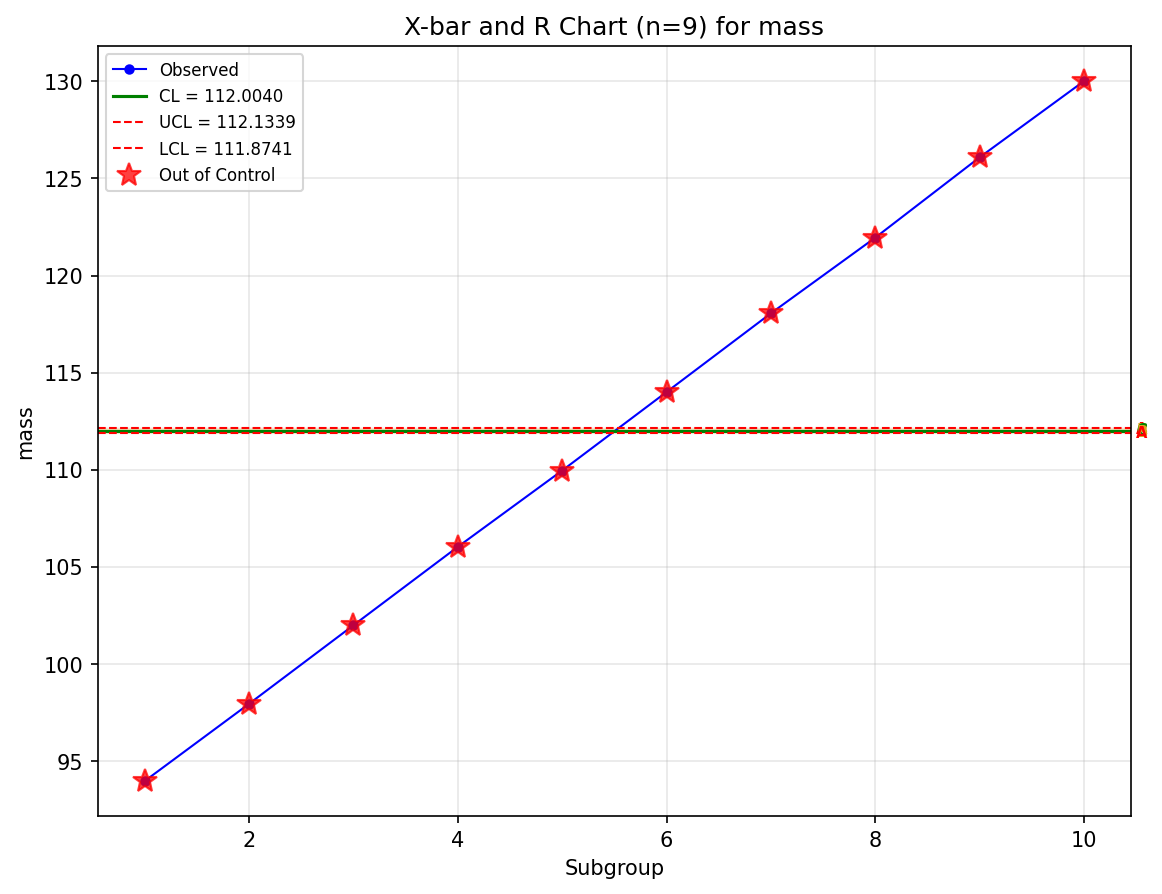

In [5]:
过程 排序 数据=calibration out=charted;
    按照 operator part;
运行;

过程 shewhart 数据=charted;
    xrchart mass*part /
        NOLEGEND
        odstitle="量具R&R：均值图与极差图";
运行;


## 第6步 - 方差分量法交叉验证（PROC MIXED）

GAGE 应用的第二个引擎是**方差分量法**，它通过 REML 拟合一个随机效应模型，并直接从
协方差参数估计中读取每个方差分量。这里我们将参考砝码作为随机效应，并配合 `COVTEST`
（似然比检验）与 `CL`（置信限）进行拟合。交叉验证针对的是*标准差*，而非极差法的原始
数字：极差法将 `PV` 报告为6-sigma研究跨度（约68克），因此其隐含的零件标准差为
`PV / 6`（约11.3克，方差约128）。REML 得到的 `Part`（零件）方差应落在同一区间内，
而较小的 `Residual`（残差）方差应与设备噪声的平方（标准差0.12克 -> 约0.014）相匹配。

          The Mixed Procedure          
           Model Information           

Item                              Value
----------------------  ---------------
Dependent Variable                质量（克）
Estimation Method                  REML
Number of Observations               90

         Covariance Parameter Estimates         

Cov Parm  Estimate     Alpha     Lower     Upper
--------  --------  --------  --------  --------
Part      146.9916    0.0500   69.5443  489.9013
Residual    0.0148    0.0500    0.0112    0.0204

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    -15.0384
AIC (Smaller is Better)  -11.0384
BIC (Smaller is Better)   -6.0388

Tests of Covariance Parameters Based on the Restricted Likelihood

Label         -2 Res Log Like        DF  Chi-Square  Pr > ChiSq
------------  ---------------  --------  ----------  ----------
Part = 0             -15.0384         1     44.5000      <.0001
Residu


NOTE: PROC MIXED data=calibration

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: mass ~ 1
NOTE: Group variable: part
NOTE: Estimation method: REML (reml=True)
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:          Mixed Linear Model Regression Results
NOTE: =======================================================
NOTE: Model:             MixedLM  Dependent Variable:  mass  
NOTE: No. Observations:  90       Method:              REML  
NOTE: No. Groups:        10       Scale:               0.0148
NOTE: Min. group size:   9        Log-Likelihood:      7.5192
NOTE: Max. group size:   9        Converged:           Yes   
NOTE: Mean group size:   9.0                                 
NOTE: -------------------------------------------------------
NOTE:            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
NOTE: -------------------------------------------------------
NOTE: Intercept 112.004

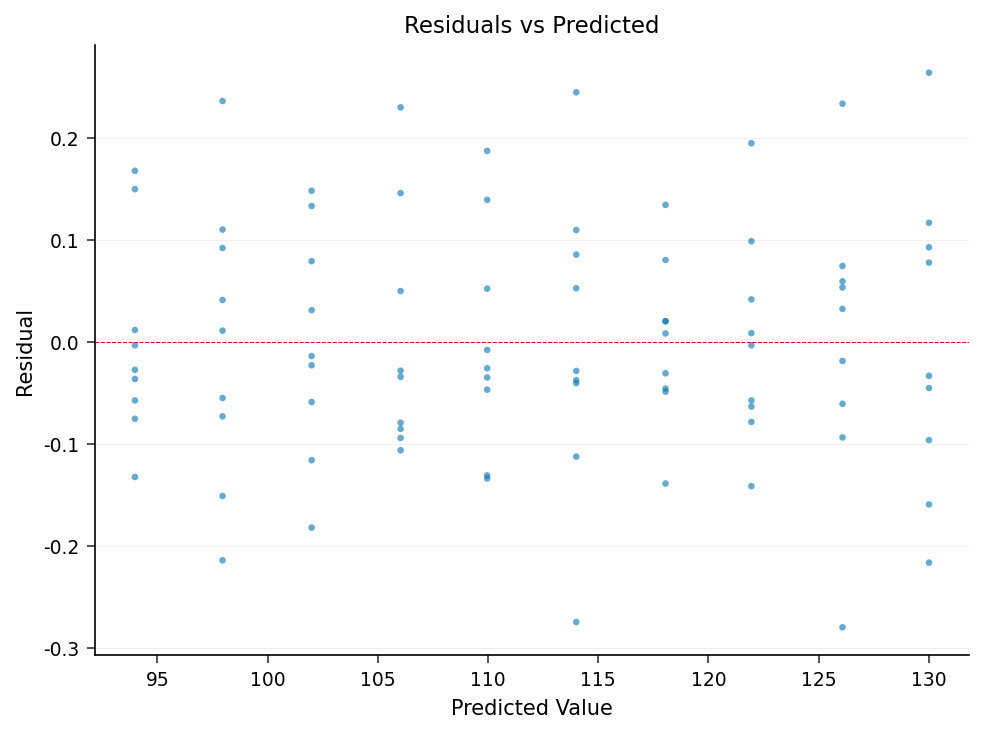

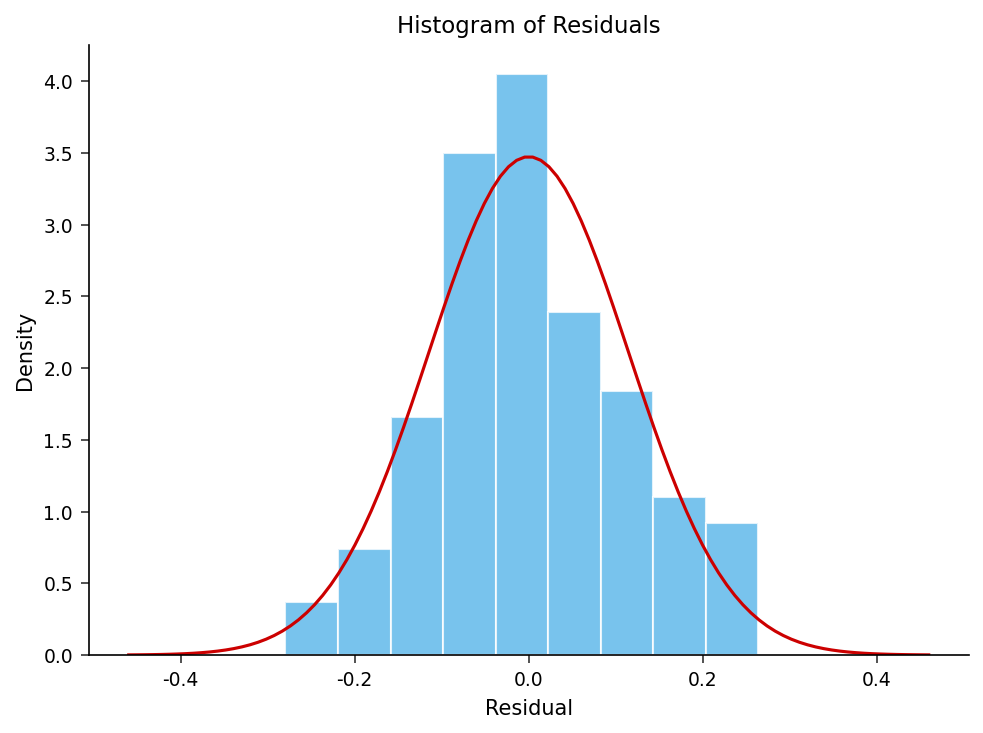

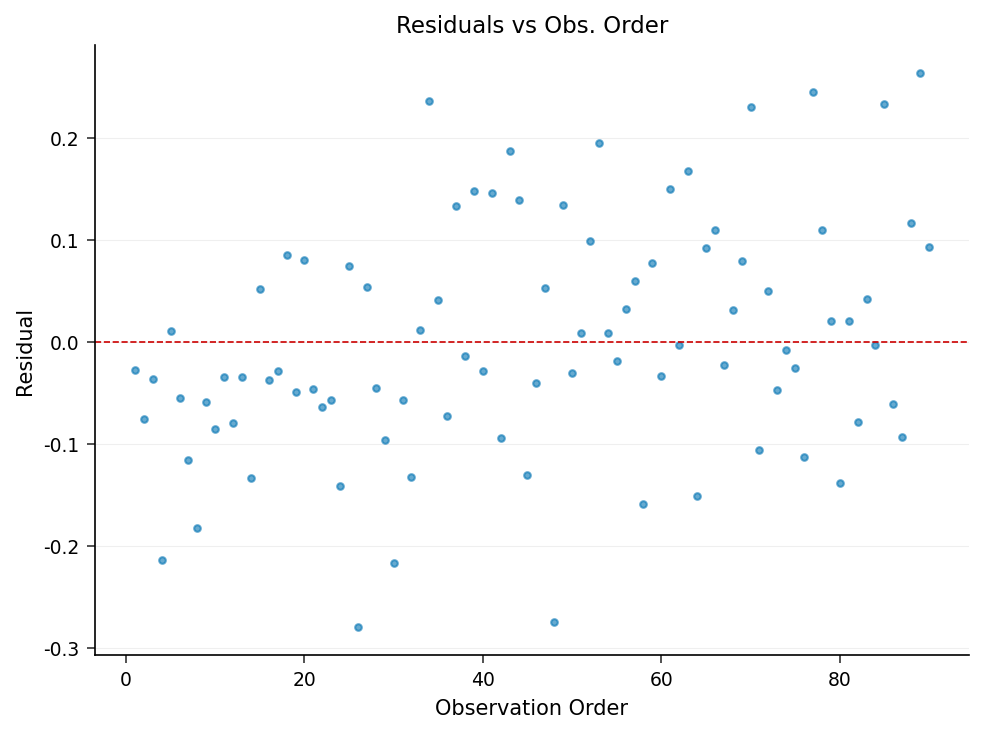

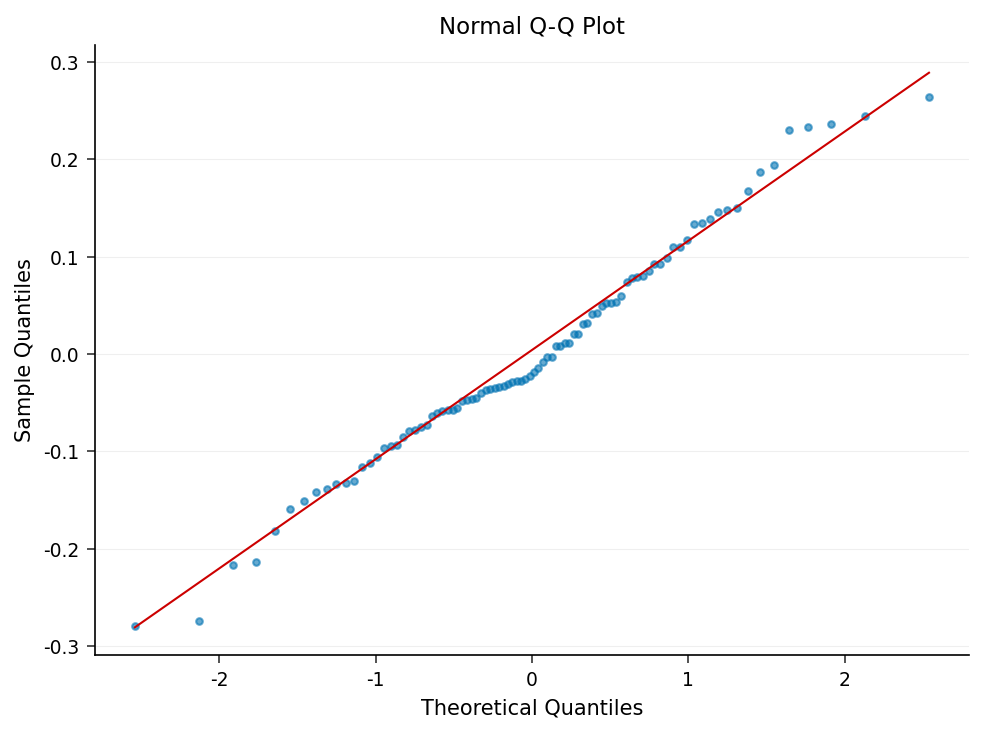

In [6]:
过程 MIXED 数据=calibration METHOD=reml covtest cl;
    分类 part;
    模型 mass = ;
    RANDOM part;
    标签 mass = "质量（克）" part = "零件";
运行;


## 结果解读

**天平认证通过。** 均值极差法报告的**%R&R 接近总变异的1%**（1.08%）——远低于
Barrentine 10%的“优异”阈值——因此观测到的离散几乎不来自测量系统。相反，**%PV 基本
为100%**（99.99%）：我们所看到的变异是十个认证砝码之间的真实差异，这正是该量具应当
捕捉到的。

**可区分类别数（ndc）。** 该研究得出130个可区分类别——远高于 AIAG 最低要求的5个——
说明该天平能够可靠地将参考砝码区分为许多可分辨的组别，为商用秤具核查提供了充裕的分辨率。

**图表相互印证。** 均值（X-bar）图显示全部十个子组均值都落在狭窄的控制限（CL 112.00、
UCL 112.13、LCL 111.87）*之外*——这是 Gage R&R 研究中理想的信号，说明量具检测到的是
真实的零件间差异而非噪声。相应的极差图控制限（R-bar 0.386，UCL 0.701）显示每个子组的
极差都在控制之内，确认了各检验员之间的重复性是稳定的。

**方差分量印证了这一点。** PROC MIXED 将几乎全部方差归于 `Part`（零件）分量
（146.99，标准差12.1克），而 `Residual`（残差）方差接近零（0.0148，标准差0.122克）。
零件标准差与极差法隐含的零件标准差（PV/6 约11.3克）以及模拟设定的真实质量差异
（11.5克）相符，而残差标准差再现了注入的0.12克设备噪声——因此重复性与再现性在统计上
和实践上都可以忽略不计。协方差参数检验在 p < .0001 的水平上拒绝了 `Part = 0`。

**对该机构的建议。** 该测量系统足以胜任商用秤具的认证工作。若要进一步收紧保证水平，
关键杠杆不在检验员（再现性已可忽略），而在设备本身——因此常规的天平重新校准，而非增加
检验员培训，才是正确的维护重点。